## This program allows you to plot the perpendicular BAO distance and the parallel BAO distance with Planck normalisation 

In [1]:
#Importing modules
import numpy as np
import matplotlib.pyplot as plt 
from fonction import trapezeVect
import matplotlib.ticker

In [2]:
#Constant 
c= 3e5
hrd = 101.54

#Planck 2018
wbP = 0.02237 ; wcP = 0.1200 ; H0P = 67.36 ; OLP = 0.6847 ; OmP = 0.3153
wmP = wbP+wcP ; hP = H0P/100 ; rdP = 147.09 ; hrdP = hP*rdP

OmCMB = 0.3169 ; H0CMB = 67.14 ; hCMB = H0CMB/100 ; OlCMB = 1-OmCMB ; hrdCMB = hCMB*rdP
OmDESI = 0.2975 ; OlDESI = 1-OmDESI
OmDC = 0.3027 ; OlDC=1-OmDC; H0DC = 68.17; hrdDC = 101.09

In [3]:
#DESI data
Zred = np.linspace(0.00001,3,50)
redshift = np.array([0.510,0.706,0.934,1.321,1.484,2.330])
DHrdexp = np.array([21.863,19.455,17.641,14.176,12.817,8.632])
DMrdexp = np.array([13.588,17.351,21.576,27.601,30.512,38.988])
IDHrd = np.array([0.425,0.330,0.193,0.221,0.516,0.101])
IDMrd = np.array([0.167,0.177,0.152,0.318,0.760,0.531])

In [4]:
#Functions 
def DHrd(z,hrd_val,Om,Ol) : 
	return c/(100*hrd_val*np.sqrt(Om*(1+z)**3+Ol))
def DMrd(z, hrd_val, Om, Ol) :
    return trapezeVect(lambda zp: DHrd(zp, hrd_val, Om, Ol), 0, z, 500)
def DHrdw(z,hrd_val,Om,Ol,w) : 
	return c/(100*hrd_val*np.sqrt(Om*(1+z)**3+Ol*(1+z)**(-3*(1+w))))

In [5]:
#distance calculation 
DHrdvec = np.vectorize(DHrd)
DHrdwvec = np.vectorize(DHrdw)

DHrdP      = np.array([DHrd(z, hrdP, OmP, OLP) for z in Zred])
DHrdP_data = np.array([DHrd(z, hrdP, OmP, OLP) for z in redshift])
DMrdP      = np.array([DMrd(z, hrdP, OmP, OLP) for z in Zred])
DMrdP_data = np.array([DMrd(z, hrdP, OmP, OLP) for z in redshift])

CMB = DHrdvec(Zred,hrdCMB,OmCMB,OlCMB)/DHrdP
DESI = DHrdvec(Zred,hrd,OmDESI,OlDESI)/DHrdP
DC = DHrdvec(Zred,hrdDC,OmDC,OlDC)/DHrdP


CMB_DM = np.array([DMrd(z, hrdP, OmCMB, OlCMB) for z in Zred]) / DMrdP
DESI_DM = np.array([DMrd(z, hrd, OmDESI, OlDESI) for z in Zred]) / DMrdP
DC_DM = np.array([DMrd(z, hrdDC, OmDC, OlDC) for z in Zred]) / DMrdP

DESIDHexp = DHrdexp/DHrdP_data
DESIDMexp = DMrdexp/DMrdP_data
IDH = IDHrd/DHrdP_data
IDM = IDMrd/DMrdP_data

DESI BAO measurements relative to distances in the fiducial cosmology based on Planck 2018 results are shown with black circles

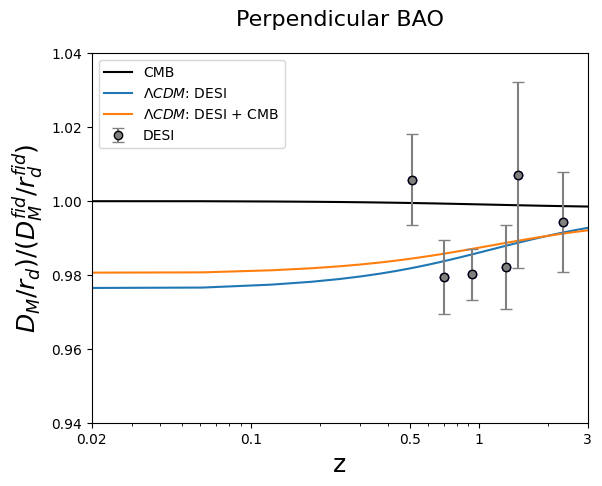

In [6]:
ticks = [0.02, 0.1, 0.5, 1, 3]

plt.figure()
plt.plot(Zred,CMB_DM,'k', label='CMB')
plt.plot(Zred,DESI_DM, label = r'$\Lambda CDM$: DESI')
plt.plot(Zred,DC_DM, label = r'$\Lambda CDM$: DESI + CMB')
plt.plot(redshift,DESIDMexp,'ob')
plt.errorbar(redshift,DESIDMexp, yerr = IDM, fmt='o',color='gray', markeredgecolor='black',capsize=4, elinewidth=1.5,label='DESI')
plt.ylim(0.94,1.04)
plt.xscale("log")
plt.xticks(ticks, labels=[str(t) for t in ticks])
plt.xlim(0.02, 3)
plt.xlabel('z',fontsize=18)
plt.ylabel(r'$D_M/r_d)/(D_M^{fid}/r_d^{fid})$',fontsize=18)
plt.title('Perpendicular BAO',pad=20,fontsize=16)
plt.legend()
#plt.savefig('perpendicularBAO_Planck.pdf',dpi=300)
plt.show()

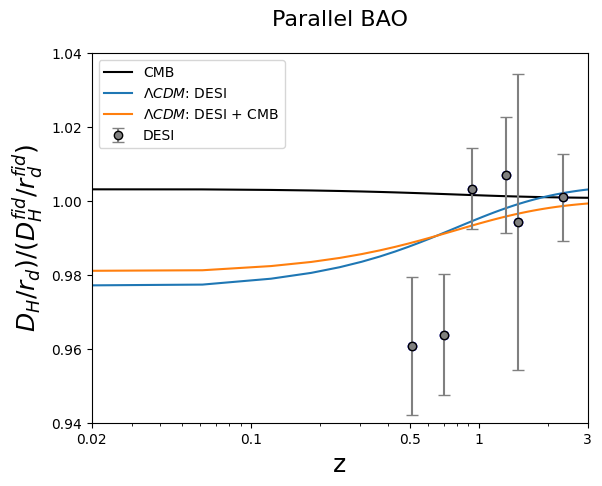

In [7]:
plt.figure()
plt.plot(Zred,CMB,'k',label='CMB')
plt.plot(Zred,DESI, label =r'$\Lambda CDM$: DESI')
plt.plot(Zred,DC,label = r'$\Lambda CDM$: DESI + CMB')
plt.plot(redshift,DESIDHexp,'ob')
plt.errorbar(redshift,DESIDHexp, yerr = IDH, fmt='o',color='gray', markeredgecolor='black',capsize=4, elinewidth=1.5,label='DESI')
plt.ylim(0.94,1.04)
plt.xscale("log")
plt.xticks(ticks, labels=[str(t) for t in ticks])
plt.xlim(0.02, 3)
plt.xlabel('z',fontsize=18)
plt.ylabel(r'$D_H/r_d)/(D_H^{fid}/r_d^{fid})$',fontsize=18)
plt.title('Parallel BAO',pad=20,fontsize=16)
plt.legend()
#plt.savefig('parallelBAO_Planck.pdf',dpi=300)
plt.show()